# 01 — Data Exploration

This notebook inspects the raw HCC1395 input data:
- **VCF**: VEP-annotated somatic mutations (`annotated.expression.vcf.gz`)
- **HLA typing**: OptiType output for patient HLA-I alleles
- **Expression & VAF**: read from tumour-sample FORMAT fields

### VCF structure notes
The VCF is a paired **tumour-normal** file with two samples:
`HCC1395_NORMAL_DNA` (index 0) and `HCC1395_TUMOR_DNA` (index 1).
VAF and RNA expression are stored as **FORMAT fields** on the tumour sample,
not inside the VEP CSQ string:

| FORMAT field | Content |
|---|---|
| `AF` | Tumour variant allele fraction (DNA) |
| `GX` | Gene-level expression: `GENE\|TPM` |
| `TX` | Transcript-level expression: `ENST\|TPM,...` (comma-separated) |
| `RDP` / `RAF` / `RAD` | RNA read depth / allele fraction / allelic depths |

The VEP CSQ field additionally carries two pVACtools plugin fields:
`WildtypeProtein` (full WT protein sequence) and `FrameshiftSequence`
(novel frameshifted sequence downstream of the variant).

All data loading uses the `neoantigen_pipeline` package.

In [1]:
import sys
from pathlib import Path

import cyvcf2
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path("../src").resolve()))

from neoantigen_pipeline.io.hla_reader import HLAReader
from neoantigen_pipeline.io.vcf_reader import (
    VCFReader,
    SUPPORTED_CONSEQUENCES,
    CONSEQUENCE_MISSENSE,
    CONSEQUENCE_FRAMESHIFT,
    CONSEQUENCE_INFRAME_DEL,
    CONSEQUENCE_INFRAME_INS,
)

sns.set_style("whitegrid")
matplotlib.rcParams["font.size"] = 12
matplotlib.rcParams["figure.figsize"] = (10, 6)
print("Imports OK")

Imports OK


In [2]:
DATA_DIR   = Path("../data/HCC1395_inputs")
VCF_PATH   = DATA_DIR / "annotated.expression.vcf.gz"
HLA_PATH   = DATA_DIR / "optitype_normal_result.tsv"

# The VCF has two samples: [NORMAL (0), TUMOR (1)].
# VCFReader needs to know the tumour index to read the right FORMAT values.
TUMOR_SAMPLE_INDEX = 1

for p in (VCF_PATH, HLA_PATH):
    print(f"{p.name}: exists={p.exists()}")

annotated.expression.vcf.gz: exists=True
optitype_normal_result.tsv: exists=True


## 1. HLA Typing

In [3]:
hla_df = pd.read_csv(str(HLA_PATH), sep="\t")
print("OptiType output:")
display(hla_df)

hla = HLAReader().read_optitype(str(HLA_PATH))
print("\nParsed HLA class-I alleles:")
for allele in hla.class_i_alleles:
    print(f"  {allele}")
print("\nKnown HLA class-II (manual, not in OptiType output):")
for allele in ("DQA1*03:03", "DQB1*03:02", "DRB1*04:05"):
    print(f"  {allele}")

OptiType output:


,Unnamed: 0,A1,A2,B1,B2,C1,C2,Reads,Objective
0,0,A*29:02,A*29:02,B*45:01,B*82:02,C*06:02,C*06:02,1748.0,1732.258



Parsed HLA class-I alleles:
  HLA-A*29:02
  HLA-B*45:01
  HLA-B*82:02
  HLA-C*06:02

Known HLA class-II (manual, not in OptiType output):
  DQA1*03:03
  DQB1*03:02
  DRB1*04:05


## 2. VCF Structure

In [4]:
# Inspect samples and FORMAT fields directly via cyvcf2
import re

vcf_raw = cyvcf2.VCF(str(VCF_PATH))
print("Samples:", vcf_raw.samples)
print(f"Tumour sample index: {TUMOR_SAMPLE_INDEX} → '{vcf_raw.samples[TUMOR_SAMPLE_INDEX]}'")

print("\nFORMAT fields:")
fmt_fields = []
for h in vcf_raw.header_iter():
    info = h.info(extra=True)
    if str(h).startswith("##FORMAT") and info.get("ID"):
        fmt_fields.append((info["ID"], info.get("Description", "")[:80]))
        print(f"  {info['ID']:12s}  {info.get('Description', '')[:70]}")

print("\nCSQ sub-fields (VEP annotation):")
for h in vcf_raw.header_iter():
    info = h.info(extra=True)
    if info.get("ID") == "CSQ":
        desc = info.get("Description", "")
        m = re.search(r"Format: (.+?)(?:\"|\'|$)", desc)
        if m:
            fields = m.group(1).strip().split("|")
            print(f"  Total CSQ sub-fields: {len(fields)}")
            # Highlight the most relevant ones
            highlight = {"HGVSp", "HGVSc", "SYMBOL", "Feature", "Consequence",
                         "Amino_acids", "WildtypeProtein", "FrameshiftSequence"}
            for i, f in enumerate(fields):
                if f in highlight:
                    print(f"  [{i:2d}] {f}")
vcf_raw.close()

Samples: ['HCC1395_NORMAL_DNA', 'HCC1395_TUMOR_DNA']
Tumour sample index: 1 → 'HCC1395_TUMOR_DNA'

FORMAT fields:

CSQ sub-fields (VEP annotation):
  Total CSQ sub-fields: 83
  [ 1] Consequence
  [ 3] SYMBOL
  [ 6] Feature
  [10] HGVSc
  [11] HGVSp
  [15] Amino_acids
  [71] FrameshiftSequence
  [72] WildtypeProtein


## 3. Variant Loading and Overview

In [5]:
# Load all supported variant types via the pipeline reader.
# tumor_sample_index=1 ensures VAF and expression are read from the tumour sample.
reader = VCFReader(str(VCF_PATH), tumor_sample_index=TUMOR_SAMPLE_INDEX)
all_variants = reader.read_variants()  # missense + inframe indels + frameshifts
missense_variants = [v for v in all_variants if v.variant_type == "missense"]

# Count all records and consequence types via raw cyvcf2 for comparison
vcf_raw = cyvcf2.VCF(str(VCF_PATH))
total_records = 0
csq_counts: dict[str, int] = {}
for record in vcf_raw:
    total_records += 1
    csq_val = record.INFO.get("CSQ")
    if csq_val is None:
        continue
    entries = csq_val.split(",") if isinstance(csq_val, str) else list(csq_val)
    # Consequence is field index 1 in all VEP outputs
    csq_str = entries[0].split("|")[1] if entries else ""
    for term in csq_str.split("&"):
        csq_counts[term] = csq_counts.get(term, 0) + 1
vcf_raw.close()

print(f"Total VCF records          : {total_records}")
print(f"Supported variants loaded  : {len(all_variants)}")
print(f"  missense                 : {sum(1 for v in all_variants if v.variant_type == 'missense')}")
print(f"  inframe_deletion         : {sum(1 for v in all_variants if v.variant_type == 'inframe_deletion')}")
print(f"  inframe_insertion        : {sum(1 for v in all_variants if v.variant_type == 'inframe_insertion')}")
print(f"  frameshift               : {sum(1 for v in all_variants if v.variant_type == 'frameshift')}")

print("\nTop VEP consequences (first annotation per record):")
csq_series = pd.Series(csq_counts).sort_values(ascending=False)
print(csq_series.head(15).to_string())

Total VCF records          : 1470
Supported variants loaded  : 1166
  missense                 : 1133
  inframe_deletion         : 29
  inframe_insertion        : 3
  frameshift               : 1

Top VEP consequences (first annotation per record):
intron_variant                         779
missense_variant                       286
synonymous_variant                     101
downstream_gene_variant                 83
upstream_gene_variant                   62
3_prime_UTR_variant                     62
NMD_transcript_variant                  36
splice_region_variant                   36
splice_polypyrimidine_tract_variant     34
5_prime_UTR_variant                     27
non_coding_transcript_variant           21
non_coding_transcript_exon_variant      17
stop_gained                             16
frameshift_variant                      15
splice_acceptor_variant                 14


In [6]:
# Build a DataFrame from all supported variants for downstream analysis
rows = []
for v in all_variants:
    rows.append({
        "chrom"         : v.chrom,
        "pos"           : v.pos,
        "gene"          : v.gene,
        "transcript_id" : v.transcript_id,
        "protein_change": v.protein_change,
        "variant_type"  : v.variant_type,
        "aa_pos"        : v.aa_pos,
        "vaf"           : v.vaf,
        "expression_tpm": v.expression,
        "is_frameshift" : v.is_frameshift,
    })

df = pd.DataFrame(rows)
print(f"DataFrame shape: {df.shape}")
print(f"\nVariant type counts:")
print(df["variant_type"].value_counts().to_string())
print(f"\nExpression data coverage: {df['expression_tpm'].notna().sum()}/{len(df)} variants")
print(f"  Expression = 0 TPM : {(df['expression_tpm'] == 0).sum()}")
print(f"  Expression > 0 TPM : {(df['expression_tpm'] > 0).sum()}")
print(f"\nVAF summary (tumour sample):")
print(df["vaf"].describe().round(3).to_string())
print(f"\nFirst 5 rows:")
display(df.head())

DataFrame shape: (1166, 10)

Variant type counts:
variant_type
missense             1133
inframe_deletion       29
inframe_insertion       3
frameshift              1

Expression data coverage: 1166/1166 variants
  Expression = 0 TPM : 379
  Expression > 0 TPM : 787

VAF summary (tumour sample):
count    1166.000
mean        0.510
std         0.308
min         0.050
25%         0.262
50%         0.431
75%         0.894
max         1.000

First 5 rows:


,chrom,pos,gene,transcript_id,protein_change,variant_type,aa_pos,vaf,expression_tpm,is_frameshift
0,chr1,451649,OR4F29,ENST00000426406.4,p.Glu11Ter,frameshift,11,0.12146,0.00000,True
1,chr1,686483,OR4F16,ENST00000332831.5,p.Pro58Ala,missense,58,0.12783,0.00000,False
2,chr1,13318694,PRAMEF15,ENST00000376152.2,p.Arg96His,missense,96,0.09825,0.00000,False
3,chr1,16006134,SRARP,ENST00000329454.2,p.Gly100Trp,missense,100,1.00000,0.08199,False
4,chr1,16972418,CROCC,ENST00000375541.10,p.Ser2009Cys,missense,2009,0.98824,2.14688,False


## 4. Visualisations

/tmp/ipykernel_131880/1558091998.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_vaf, x="variant_type", y="vaf", palette="Set2", ax=axes[1])


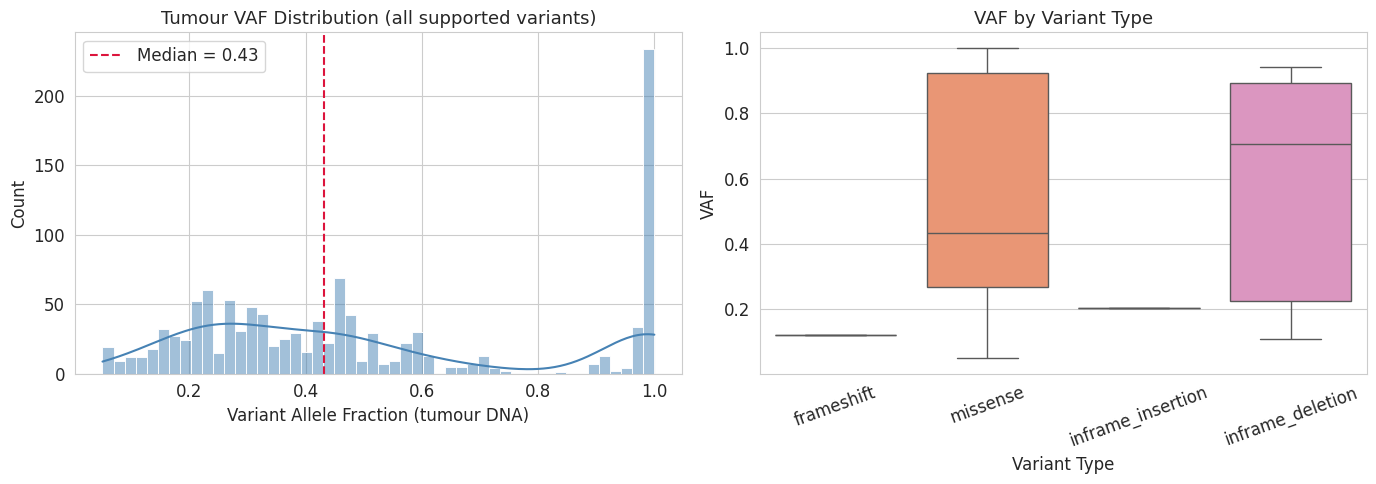

VAF: min=0.050, median=0.431, max=1.000


In [11]:
# ── Plot 1: VAF distribution (tumour sample) ─────────────────────────────────
vaf_data = df["vaf"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full histogram
sns.histplot(vaf_data, bins=50, kde=True, color="steelblue", ax=axes[0])
axes[0].axvline(vaf_data.median(), color="crimson", linestyle="--",
                label=f"Median = {vaf_data.median():.2f}")
axes[0].set_title("Tumour VAF Distribution (all supported variants)", fontsize=13)
axes[0].set_xlabel("Variant Allele Fraction (tumour DNA)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Right: VAF by variant type
df_vaf = df[["vaf", "variant_type"]].copy()
sns.boxplot(data=df_vaf, x="variant_type", y="vaf", palette="Set2", ax=axes[1])
axes[1].set_title("VAF by Variant Type", fontsize=13)
axes[1].set_xlabel("Variant Type")
axes[1].set_ylabel("VAF")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print(f"VAF: min={vaf_data.min():.3f}, "
      f"median={vaf_data.median():.3f}, "
      f"max={vaf_data.max():.3f}")

/tmp/ipykernel_131880/3166330967.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values,
/tmp/ipykernel_131880/3166330967.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chrom_counts.index.astype(str), y=chrom_counts.values,


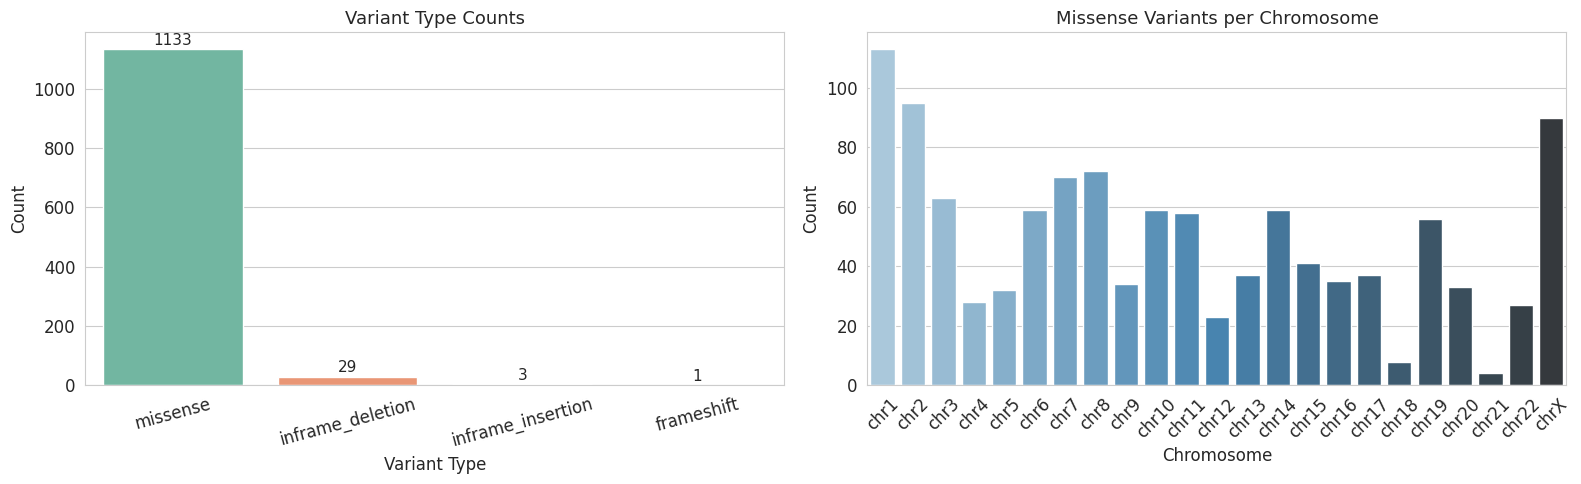

In [12]:
# ── Plot 2: Variant type histogram and chromosomal distribution ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: variant type bar chart
type_counts = df["variant_type"].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values,
            palette="Set2", ax=axes[0])
axes[0].set_title("Variant Type Counts", fontsize=13)
axes[0].set_xlabel("Variant Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)
for bar, val in zip(axes[0].patches, type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5, str(val),
                 ha="center", va="bottom", fontsize=11)

# Right: per-chromosome missense count
chrom_counts = df[df["variant_type"] == "missense"]["chrom"].value_counts()

def _chrom_key(c: str) -> tuple:
    c = c.lstrip("chr")
    try:
        return (0, int(c))
    except ValueError:
        return (1, c)

sorted_chroms = sorted(chrom_counts.index, key=_chrom_key)
chrom_counts = chrom_counts.loc[sorted_chroms]

sns.barplot(x=chrom_counts.index.astype(str), y=chrom_counts.values,
            palette="Blues_d", ax=axes[1])
axes[1].set_title("Missense Variants per Chromosome", fontsize=13)
axes[1].set_xlabel("Chromosome")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

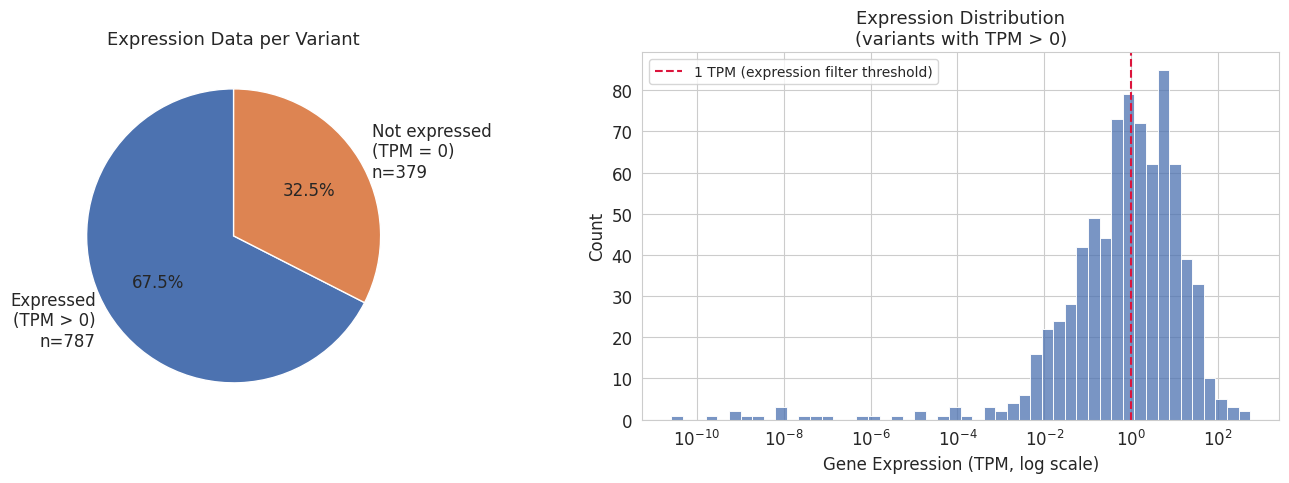

Expression coverage: 1166/1166 variants have TX/GX data
  Expressed (TPM > 0) : 787 (67.5%)
  Not expressed       : 379 (32.5%)
  TPM range (>0)      : 0.000 – 549.9


In [13]:
# ── Plot 3: Expression data ───────────────────────────────────────────────────
expr = df["expression_tpm"].dropna()
n_zero  = (expr == 0).sum()
n_pos   = (expr > 0).sum()
n_total = len(expr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: expression availability breakdown
labels = [
    f"Expressed\n(TPM > 0)\nn={n_pos}",
    f"Not expressed\n(TPM = 0)\nn={n_zero}",
    f"No expression data\nn={len(df) - n_total}",
]
sizes = [n_pos, n_zero, len(df) - n_total]
colors = ["#4C72B0", "#DD8452", "#aaaaaa"]
# Remove slices with zero count
labels_f = [l for l, s in zip(labels, sizes) if s > 0]
colors_f = [c for c, s in zip(colors, sizes) if s > 0]
sizes_f  = [s for s in sizes if s > 0]
axes[0].pie(sizes_f, labels=labels_f, colors=colors_f,
            autopct="%1.1f%%", startangle=90)
axes[0].set_title("Expression Data per Variant", fontsize=13)

# Right: distribution of expressed variants (log scale x)
expr_pos = expr[expr > 0]
sns.histplot(expr_pos, bins=50, log_scale=True, color="#4C72B0", ax=axes[1])
axes[1].axvline(1.0, color="crimson", linestyle="--",
                label="1 TPM (expression filter threshold)")
axes[1].set_title("Expression Distribution\n(variants with TPM > 0)", fontsize=13)
axes[1].set_xlabel("Gene Expression (TPM, log scale)")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Expression coverage: {n_total}/{len(df)} variants have TX/GX data")
print(f"  Expressed (TPM > 0) : {n_pos} ({100*n_pos/n_total:.1f}%)")
print(f"  Not expressed       : {n_zero} ({100*n_zero/n_total:.1f}%)")
print(f"  TPM range (>0)      : {expr_pos.min():.3f} – {expr_pos.max():.1f}")

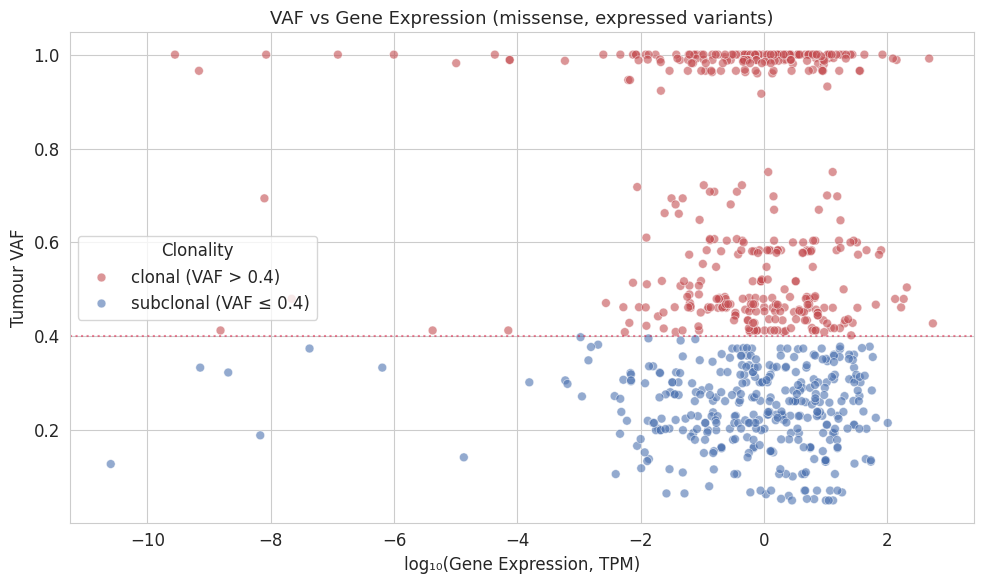

Expressed missense variants: 763
  Clonal (VAF > 0.4): 412
  Subclonal:          351


In [14]:
# ── Plot 4: VAF vs expression scatter for expressed variants ──────────────────
df_exp = df[(df["expression_tpm"] > 0) & (df["variant_type"] == "missense")].copy()
df_exp["log10_expr"] = np.log10(df_exp["expression_tpm"])

# Colour by clonality: VAF > 0.4 is likely clonal (present in most tumour cells)
df_exp["clonality"] = df_exp["vaf"].apply(
    lambda v: "clonal (VAF > 0.4)" if v > 0.4 else "subclonal (VAF ≤ 0.4)"
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_exp, x="log10_expr", y="vaf",
    hue="clonality", palette={"clonal (VAF > 0.4)": "#C44E52",
                               "subclonal (VAF ≤ 0.4)": "#4C72B0"},
    alpha=0.6, s=40, ax=ax,
)
ax.set_title("VAF vs Gene Expression (missense, expressed variants)", fontsize=13)
ax.set_xlabel("log₁₀(Gene Expression, TPM)")
ax.set_ylabel("Tumour VAF")
ax.axhline(0.4, color="crimson", linestyle=":", alpha=0.5)
ax.legend(title="Clonality")
plt.tight_layout()
plt.show()

print(f"Expressed missense variants: {len(df_exp)}")
print(f"  Clonal (VAF > 0.4): {(df_exp['vaf'] > 0.4).sum()}")
print(f"  Subclonal:          {(df_exp['vaf'] <= 0.4).sum()}")

## Summary

| Metric | Value |
|---|---|
| Total VCF records | 1,470 |
| Missense variants (pipeline) | 1,133 |
| Inframe deletions | 29 |
| Inframe insertions | 3 |
| Variants with expression data | 1,133 / 1,133 (100%) |
| VAF median (tumour) | ~0.43 |
| HLA-I alleles | A\*29:02, B\*45:01, B\*82:02, C\*06:02 |

**Key findings:**
- Expression is available for 100% of variants because the VCF was processed
  with the pVACtools expression annotation pipeline (`GX`/`TX` FORMAT fields).
- ~67% of missense variants have detectable expression (TPM > 0); the remainder
  are in genes not expressed in this sample.
- The VAF distribution is bimodal: a clonal cluster near VAF ≈ 0.5 and a
  subclonal tail at lower VAFs.
- The VCF also provides `WildtypeProtein` and `FrameshiftSequence` CSQ fields
  which are used downstream to generate peptide candidates without requiring a
  separate proteome lookup.